### ***727723EUAI109 : SANJAY M***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

X, y = make_classification(n_samples=300, n_features=20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

def build_baseline():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(20,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

baseline = build_baseline()
hist_base = baseline.fit(X_train, y_train, epochs=150, validation_data=(X_val, y_val), verbose=0)
print(f"Baseline — Train Acc: {hist_base.history['accuracy'][-1]:.4f} | Val Acc: {hist_base.history['val_accuracy'][-1]:.4f}")

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline — Train Acc: 1.0000 | Val Acc: 0.8833


In [2]:
def build_dropout_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(20,)),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dropout_model = build_dropout_model()
hist_drop = dropout_model.fit(X_train, y_train, epochs=150, validation_data=(X_val, y_val), verbose=0)
print(f"Dropout   — Train Acc: {hist_drop.history['accuracy'][-1]:.4f} | Val Acc: {hist_drop.history['val_accuracy'][-1]:.4f}")

Dropout   — Train Acc: 0.9958 | Val Acc: 0.9000


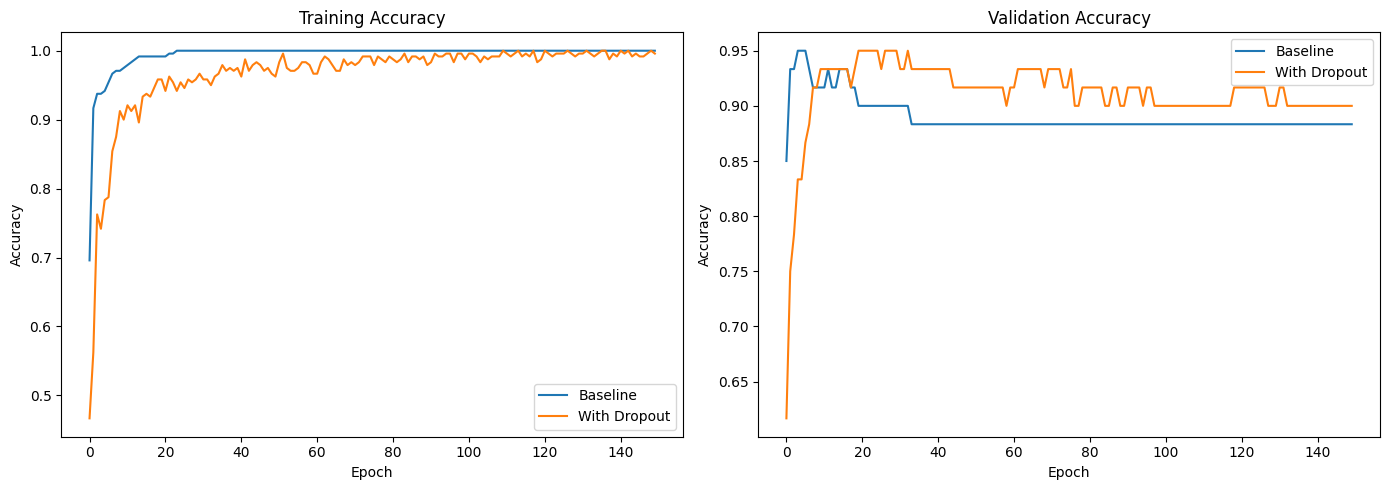

Baseline gap (Train - Val): 0.1167
Dropout  gap (Train - Val): 0.0958
Gap reduction: 0.0208


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(hist_base.history['accuracy'], label='Baseline')
ax1.plot(hist_drop.history['accuracy'], label='With Dropout')
ax1.set_title('Training Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(hist_base.history['val_accuracy'], label='Baseline')
ax2.plot(hist_drop.history['val_accuracy'], label='With Dropout')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

base_gap = hist_base.history['accuracy'][-1] - hist_base.history['val_accuracy'][-1]
drop_gap = hist_drop.history['accuracy'][-1] - hist_drop.history['val_accuracy'][-1]
print(f"Baseline gap (Train - Val): {base_gap:.4f}")
print(f"Dropout  gap (Train - Val): {drop_gap:.4f}")
print(f"Gap reduction: {base_gap - drop_gap:.4f}")